# Social Doors Representational Similarity Analysis

In [2]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from nltools.data import Brain_Data, Adjacency
from nltools.mask import expand_mask
from nltools.stats import fdr, threshold, fisher_r_to_z, one_sample_permutation
from sklearn.metrics import pairwise_distances
from nilearn.plotting import plot_glass_brain, plot_stat_map

In [3]:
#bids_dir = '/data/projects/social_doors/'
bids_dir = '/Volumes/HP-SOC-DOOR/social_doors/'

os.chdir(bids_dir)

outp_dir = os.path.join(bids_dir, 'derivatives', 'rsa-bw_runs')
data_dir = os.path.join(bids_dir, 'derivatives','social_doors-nilearn-indiv_runs')

if os.path.exists(outp_dir):
    print('Output directory already exists. Continuing will overwrite data.')
else:
    os.makedirs(outp_dir)

Output directory already exists. Continuing will overwrite data.


In [4]:
subjs_scan_info = pd.read_csv(bids_dir+'derivatives/participants_good.tsv', sep='\t')

subjs_list = list(subjs_scan_info['participant_id'].unique())
len(subjs_list)

subjs_list.sort()
subjs_list.remove('sub-3880')
subjs_list.remove('sub-4069')
print('Found '+str(len(subjs_list))+' subjects')
subj = subjs_list[0]

file_list = glob.glob(os.path.join(data_dir, subj, f'zmap*.nii'))
file_list.sort()
#file_list = file_list[:-2]
print('Found '+str(len(file_list))+' zmaps maps for '+subj)

#conditions = [os.path.basename(x)[:-7].split('beta_')[-1] for x in file_list]

#beta = Brain_Data(file_list)

Found 61 subjects
Found 24 zmaps maps for sub-010


In [5]:
print(subjs_list)

['sub-010', 'sub-013', 'sub-028', 'sub-036', 'sub-3845', 'sub-3846', 'sub-3848', 'sub-3849', 'sub-3852', 'sub-3855', 'sub-3864', 'sub-3865', 'sub-3874', 'sub-3883', 'sub-3886', 'sub-3887', 'sub-3890', 'sub-3892', 'sub-3893', 'sub-3895', 'sub-3912', 'sub-3920', 'sub-3967', 'sub-3989', 'sub-4011', 'sub-4017', 'sub-4018', 'sub-4019', 'sub-4020', 'sub-5049', 'sub-5051', 'sub-5054', 'sub-5058', 'sub-5064', 'sub-5067', 'sub-5068', 'sub-5082', 'sub-5083', 'sub-5084', 'sub-5085', 'sub-5090', 'sub-5091', 'sub-5092', 'sub-5093', 'sub-5094', 'sub-5095', 'sub-5098', 'sub-5102', 'sub-5108', 'sub-5125', 'sub-5126', 'sub-5130', 'sub-5131', 'sub-5133', 'sub-5136', 'sub-5140', 'sub-5145', 'sub-6003', 'sub-6004', 'sub-6005', 'sub-6006']


In [6]:
subjs_scan_info


,Unnamed: 0,participant_id,age,sex,group
0,0,sub-010,13,F,kid
1,2,sub-013,13,M,kid
2,5,sub-028,15,M,kid
3,6,sub-036,16,F,kid
4,7,sub-5049,12,F,kid
...,...,...,...,...,...
58,76,sub-4069,22,F,college
59,77,sub-6003,23,M,college
60,78,sub-6004,19,M,college
61,79,sub-6005,21,F,college


In [7]:
conditions = ['negative','negative_win','negative_loss',
             'positive','positive_win','positive_loss']

# Hypothesis RDMs

## Localization of monterary and social reward processing
### Hypothesis
The cerebellum will process monetary and social reward processing in separate regions within the cerebellum. These regions will be sensitive to teh valence of each domain.

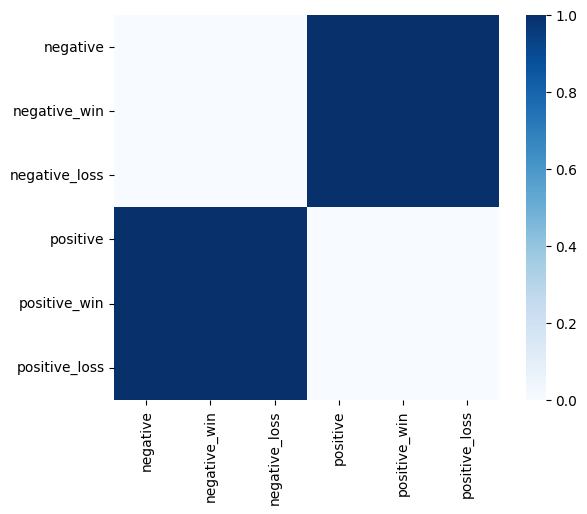

In [8]:
valence_df = pd.DataFrame([[0,0,0,1,1,1],
                          [0,0,0,1,1,1],
                          [0,0,0,1,1,1],
                          [1,1,1,0,0,0],
                          [1,1,1,0,0,0],
                          [1,1,1,0,0,0]],
                         index=conditions, columns=conditions)

valence_adj = Adjacency(valence_df, matrix_type='distance', labels=conditions)
f = valence_adj.plot(cmap=sns.color_palette("Blues", as_cmap=True))

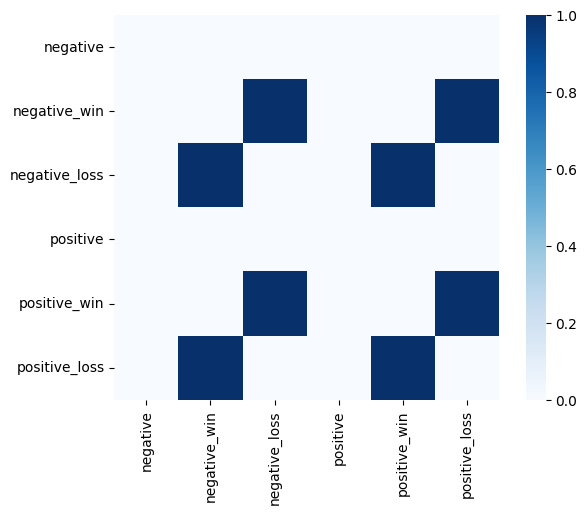

In [9]:
correct_df = pd.DataFrame([[0,0,0,0,0,0],
                          [0,0,1,0,0,1],
                          [0,1,0,0,1,0],
                          [0,0,0,0,0,0],
                          [0,0,1,0,0,1],
                          [0,1,0,0,1,0]],
                         index=conditions, columns=conditions)

correct_adj = Adjacency(correct_df, matrix_type='distance', labels=conditions)
f = correct_adj.plot(cmap=sns.color_palette("Blues", as_cmap=True))

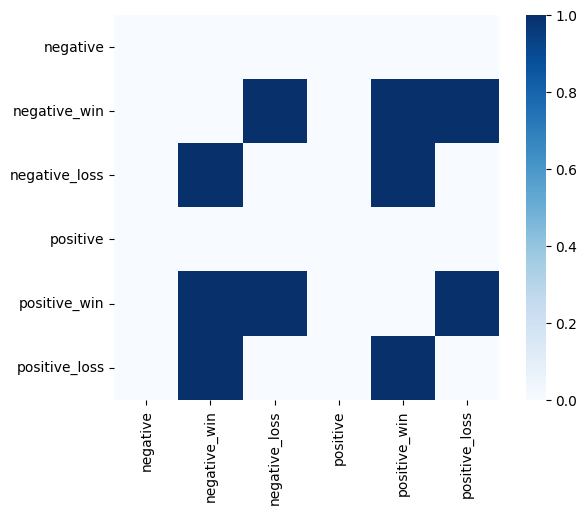

In [10]:
crctval_df = pd.DataFrame([[0,0,0,0,0,0],
                          [0,1,1,0,1,1],
                          [0,1,0,0,1,0],
                          [0,0,0,0,0,0],
                          [0,1,1,0,1,1],
                          [0,1,0,0,1,0]],
                         index=conditions, columns=conditions)

crctval_adj = Adjacency(crctval_df, matrix_type='distance', labels=conditions)
f = crctval_adj.plot(cmap=sns.color_palette("Blues", as_cmap=True))

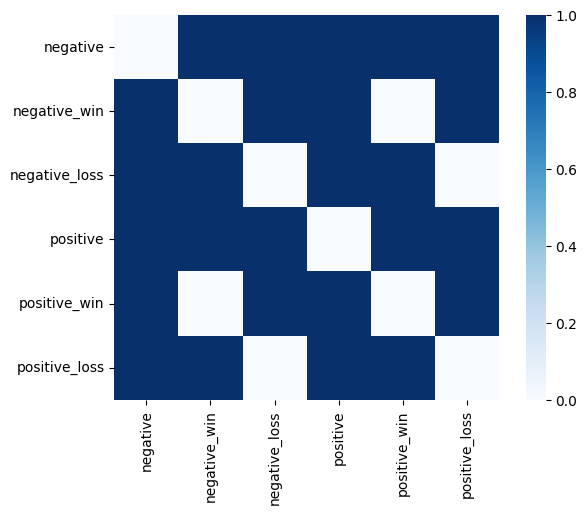

In [11]:
crctexc_df = pd.DataFrame([[0,1,1,1,1,1],
                          [1,0,1,1,0,1],
                          [1,1,0,1,1,0],
                          [1,1,1,0,1,1],
                          [1,0,1,1,0,1],
                          [1,1,0,1,1,0]],
                         index=conditions, columns=conditions)

crctexc_adj = Adjacency(crctexc_df, matrix_type='distance', labels=conditions)
f = crctexc_adj.plot(cmap=sns.color_palette("Blues", as_cmap=True))

# Reward Processing

In [12]:
# Import ROIs
reward_roi_list = glob.glob(os.path.join(bids_dir,'derivatives','rois', f'roi_bin_reward_*.nii.gz'))
reward_roi_names = [os.path.basename(x)[:-7].split('roi_bin_reward_')[-1] for x in reward_roi_list]

reward_roi_dict = dict(zip(reward_roi_names, reward_roi_list))


print(reward_roi_dict)


{'VS_l': '/Volumes/HP-SOC-DOOR/social_doors/derivatives/rois/roi_bin_reward_VS_l.nii.gz', 'VS_r': '/Volumes/HP-SOC-DOOR/social_doors/derivatives/rois/roi_bin_reward_VS_r.nii.gz', 'vmPFC_b': '/Volumes/HP-SOC-DOOR/social_doors/derivatives/rois/roi_bin_reward_vmPFC_b.nii.gz'}


/opt/anaconda3/envs/nltools/lib/python3.11/site-packages/nltools/data/brain_data.py:239: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  self.data = self.nifti_masker.fit_transform(data)
/opt/anaconda3/envs/nltools/lib/python3.11/site-packages/nltools/data/brain_data.py:239: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  self.data = self.nifti_masker.fit_transform(data)
/opt/anaconda3/envs/nltools/lib/python3.11/site-packages/nltools/data/brain_data.py:239: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  self.data = self.nifti_masker.fit_transform(data)


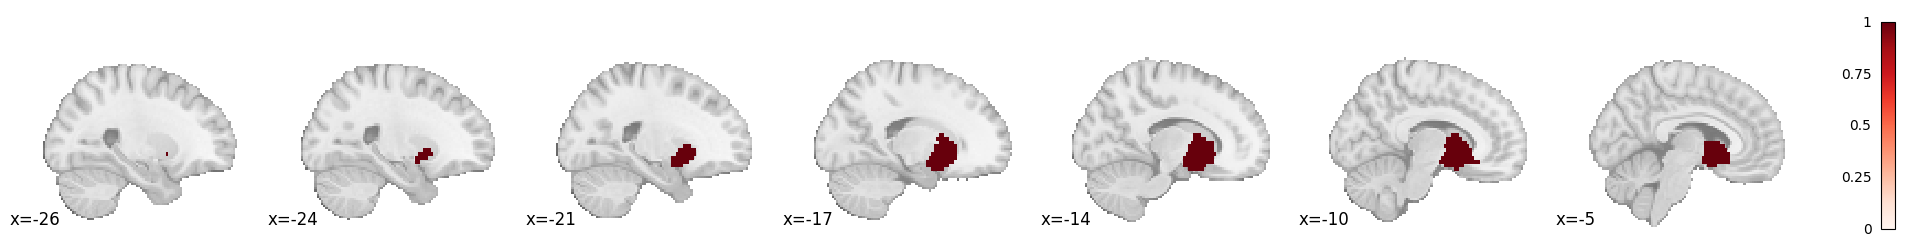

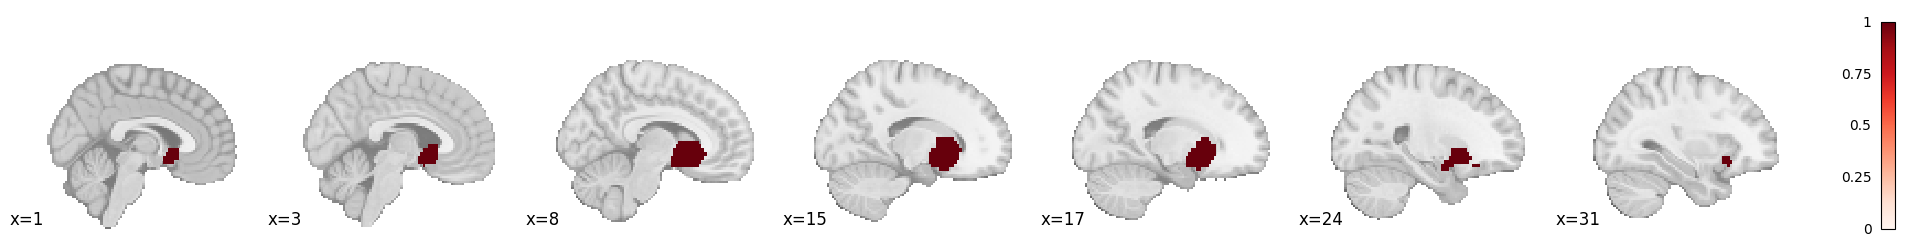

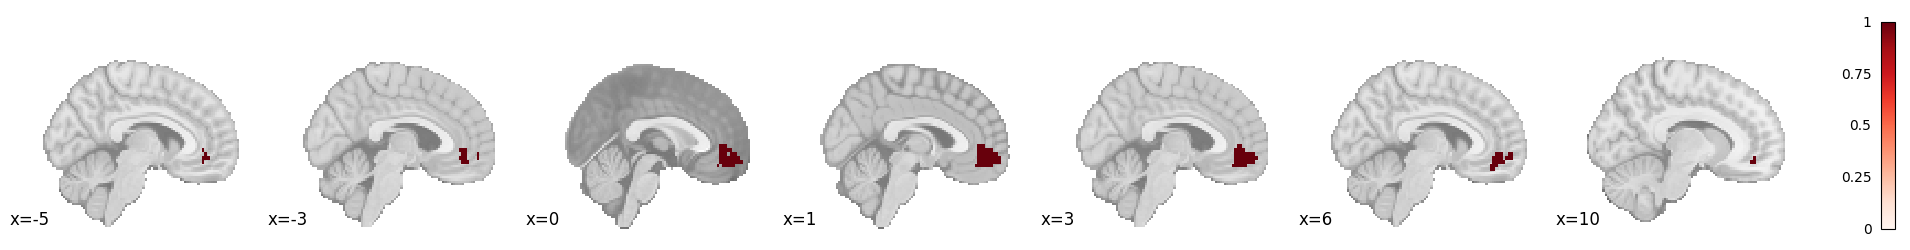

In [13]:
# Import ROIs
for n in range(len(reward_roi_names)):
    temp_roi = Brain_Data(reward_roi_list[n], mask=reward_roi_list[n])
    
    plot_stat_map(temp_roi.to_nifti(), 
                 display_mode='x',
                 cmap='Reds')

In [14]:
# Import ROIs
striat_roi_list = glob.glob(os.path.join(bids_dir,'derivatives','rois', f'striatum_*.nii.gz'))
striat_roi_names = [os.path.basename(x)[:-7].split('rois/')[-1] for x in striat_roi_list]

striat_roi_dict = dict(zip(striat_roi_names, striat_roi_list))


print(striat_roi_dict)

{'striatum_dorsala': '/Volumes/HP-SOC-DOOR/social_doors/derivatives/rois/striatum_dorsala.nii.gz', 'striatum_dorsalp': '/Volumes/HP-SOC-DOOR/social_doors/derivatives/rois/striatum_dorsalp.nii.gz', 'striatum_ventral': '/Volumes/HP-SOC-DOOR/social_doors/derivatives/rois/striatum_ventral.nii.gz'}


/opt/anaconda3/envs/nltools/lib/python3.11/site-packages/nltools/data/brain_data.py:239: UserWarning: Data array used to create a new image contains 64-bit ints. This is likely due to creating the array with numpy and passing `int` as the `dtype`. Many tools such as FSL and SPM cannot deal with int64 in Nifti images, so for compatibility the data has been converted to int32.
  self.data = self.nifti_masker.fit_transform(data)
/opt/anaconda3/envs/nltools/lib/python3.11/site-packages/nltools/data/brain_data.py:239: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  self.data = self.nifti_masker.fit_transform(data)
/opt/anaconda3/envs/nltools/lib/python3.11/site-packages/nltools/data/brain_data.py:239: UserWarning: Data array used to create a new image contains 64-bit ints. This is likely due to creating the array with numpy and passing `int` as the `dtype`. Many tools such as FSL and 

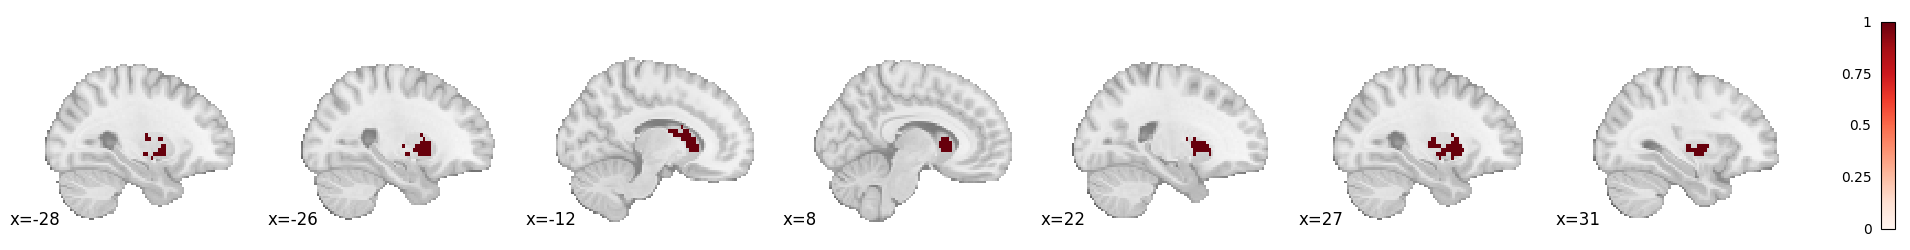

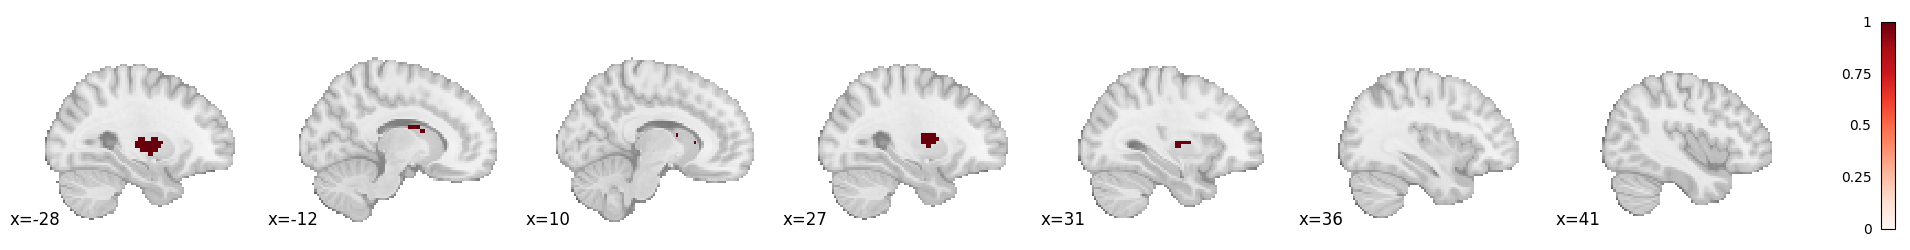

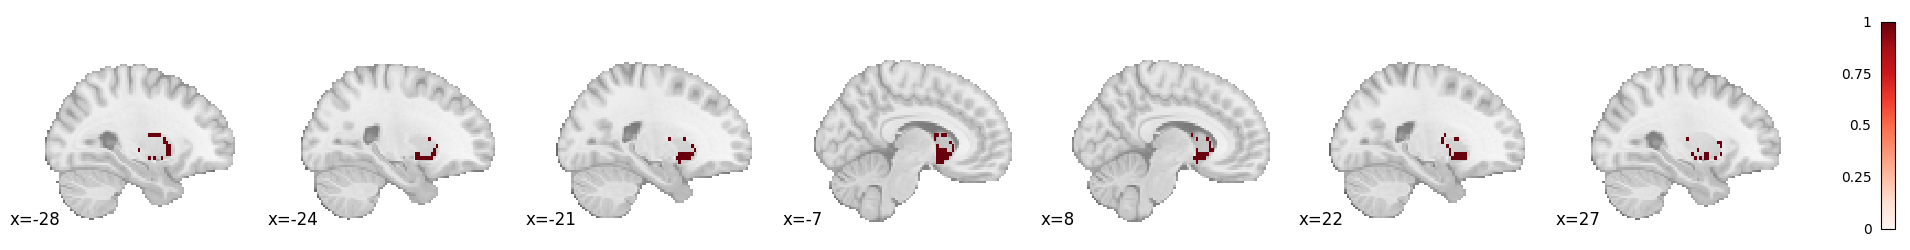

In [15]:
# Import ROIs
for n in range(len(striat_roi_names)):
    temp_roi = Brain_Data(striat_roi_list[n], mask=striat_roi_list[n])
    
    plot_stat_map(temp_roi.to_nifti(), 
                 display_mode='x',
                 cmap='Reds')

In [16]:
# Import ROIs
social_roi_list = glob.glob(os.path.join(bids_dir,'derivatives','rois', f'roi_bin_social_*.nii.gz'))
social_roi_names = [os.path.basename(x)[:-7].split('roi_bin_social_')[-1] for x in social_roi_list]

social_roi_dict = dict(zip(social_roi_names, social_roi_list))


print(social_roi_dict)

{'AMG_r': '/Volumes/HP-SOC-DOOR/social_doors/derivatives/rois/roi_bin_social_AMG_r.nii.gz', 'ATL_b': '/Volumes/HP-SOC-DOOR/social_doors/derivatives/rois/roi_bin_social_ATL_b.nii.gz', 'ATL_l': '/Volumes/HP-SOC-DOOR/social_doors/derivatives/rois/roi_bin_social_ATL_l.nii.gz', 'ATL_r': '/Volumes/HP-SOC-DOOR/social_doors/derivatives/rois/roi_bin_social_ATL_r.nii.gz', 'C1_r': '/Volumes/HP-SOC-DOOR/social_doors/derivatives/rois/roi_bin_social_C1_r.nii.gz', 'PCC_b': '/Volumes/HP-SOC-DOOR/social_doors/derivatives/rois/roi_bin_social_PCC_b.nii.gz', 'TPJ_b': '/Volumes/HP-SOC-DOOR/social_doors/derivatives/rois/roi_bin_social_TPJ_b.nii.gz', 'TPJ_l': '/Volumes/HP-SOC-DOOR/social_doors/derivatives/rois/roi_bin_social_TPJ_l.nii.gz', 'TPJ_r': '/Volumes/HP-SOC-DOOR/social_doors/derivatives/rois/roi_bin_social_TPJ_r.nii.gz', 'dmPFC_b': '/Volumes/HP-SOC-DOOR/social_doors/derivatives/rois/roi_bin_social_dmPFC_b.nii.gz'}


/opt/anaconda3/envs/nltools/lib/python3.11/site-packages/nltools/data/brain_data.py:239: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  self.data = self.nifti_masker.fit_transform(data)
/opt/anaconda3/envs/nltools/lib/python3.11/site-packages/nltools/data/brain_data.py:239: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  self.data = self.nifti_masker.fit_transform(data)
/opt/anaconda3/envs/nltools/lib/python3.11/site-packages/nltools/data/brain_data.py:239: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  self.data = self.nifti_masker.fit_transform(data)
/opt/anaconda3/envs/nltools/lib/python3.11/site-packages/nltools/data/brain_data.py:239: UserWarning: [NiftiMasker.

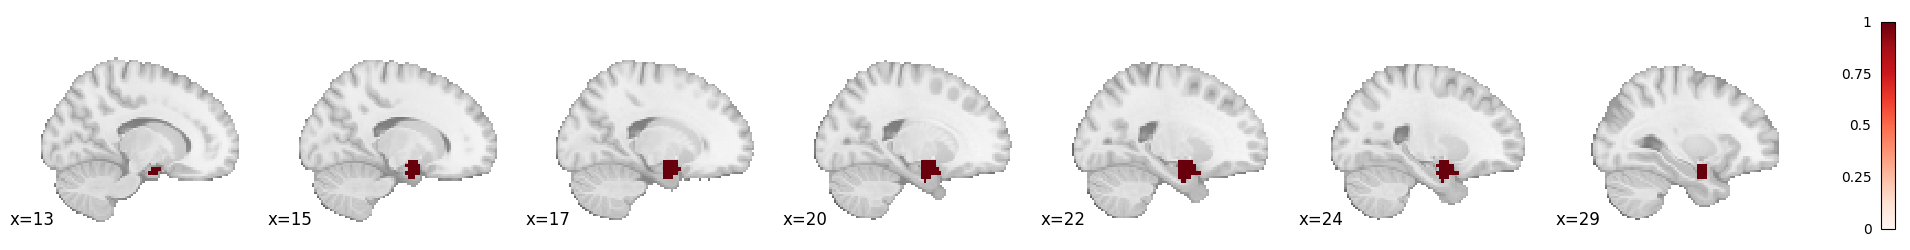

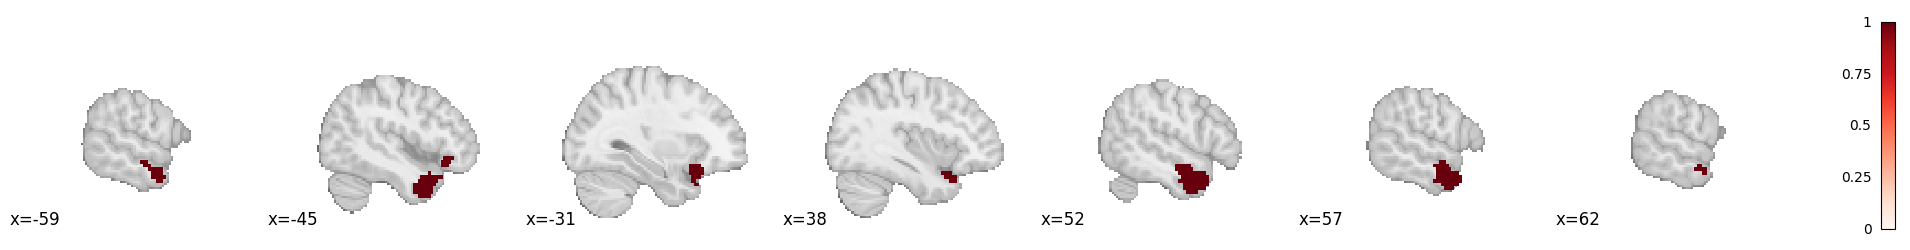

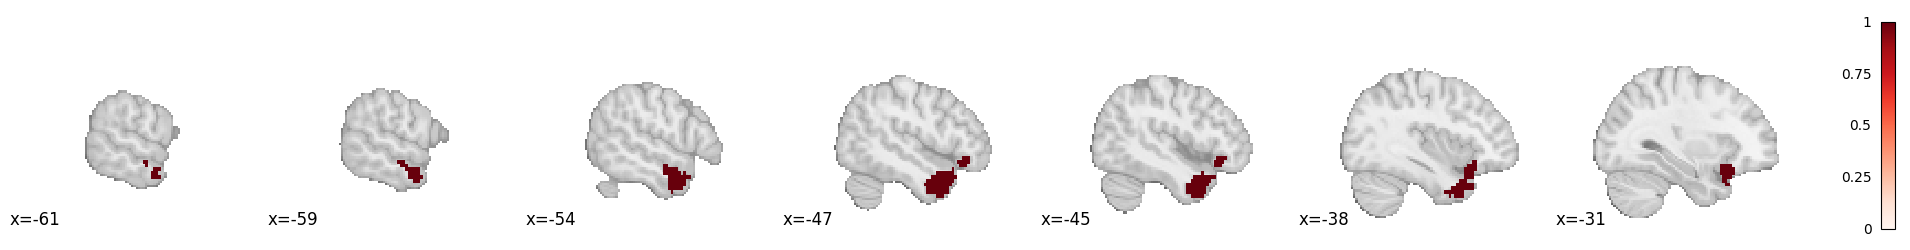

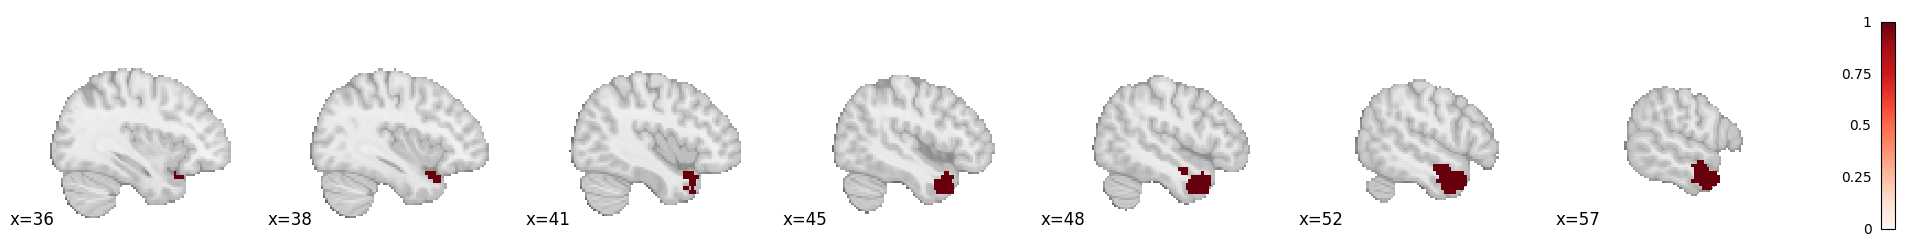

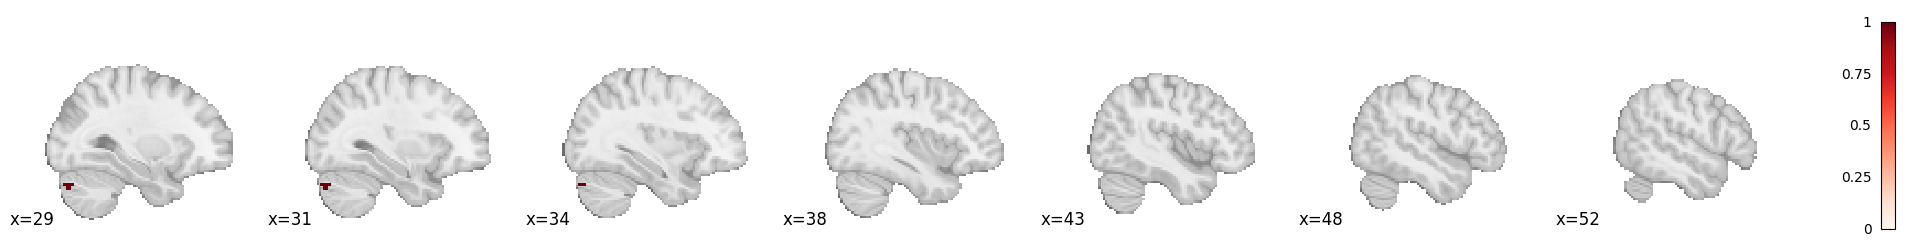

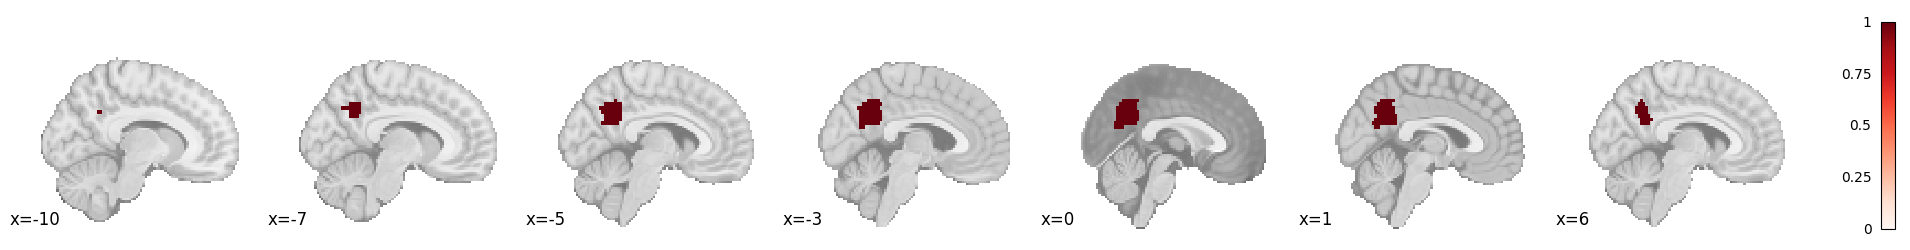

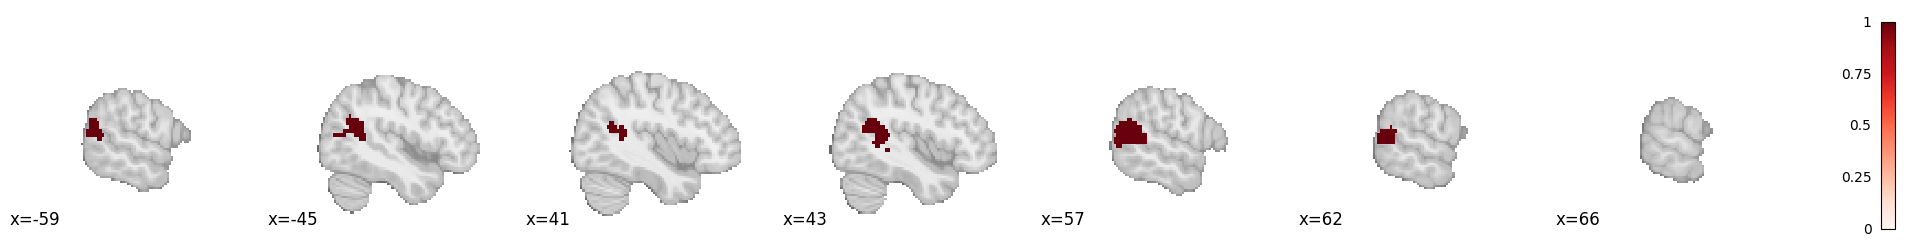

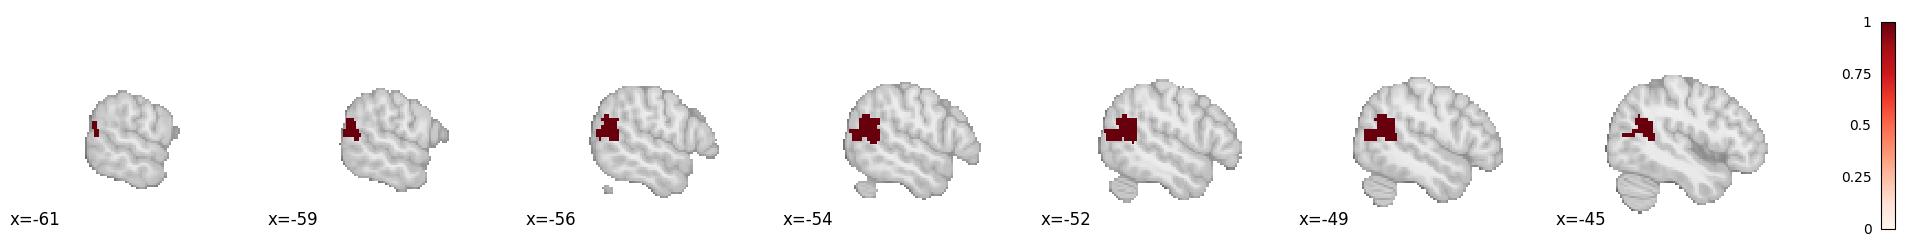

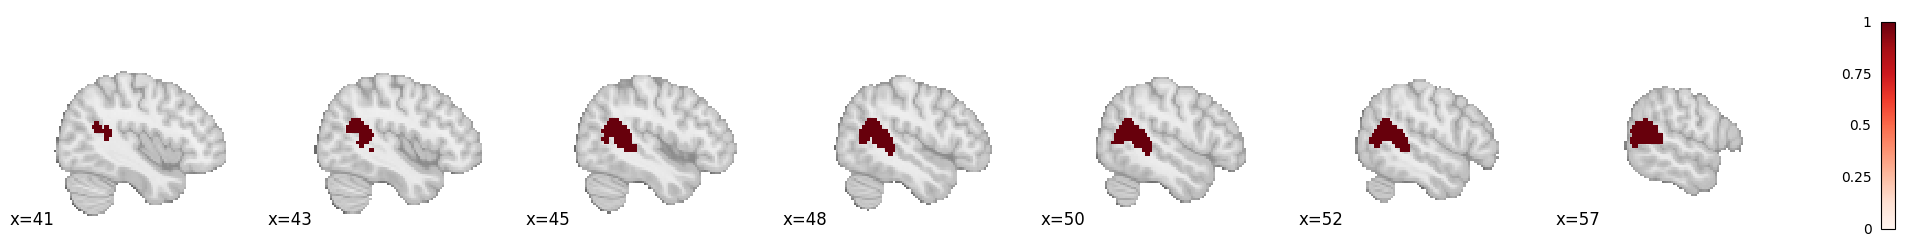

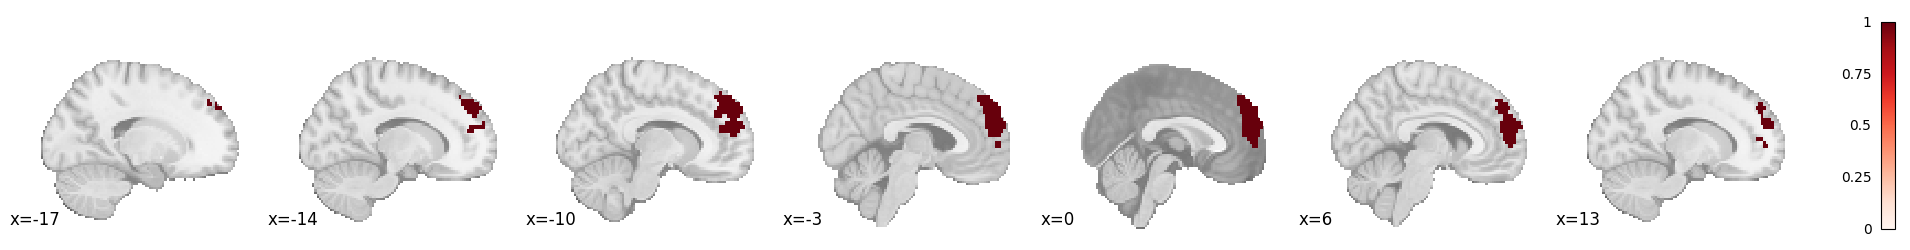

In [17]:
# Import ROIs
for n in range(len(social_roi_names)):
    temp_roi = Brain_Data(social_roi_list[n], mask=social_roi_list[n])
    
    plot_stat_map(temp_roi.to_nifti(), 
                 display_mode='x',
                 cmap='Reds')

In [18]:
# Import ROIs
mdtbcb_roi_list = glob.glob(os.path.join(bids_dir,'derivatives','rois', f'mdtb_*.nii.gz'))
mdtbcb_roi_names = [os.path.basename(x)[:-7].split('mdtb_')[-1] for x in mdtbcb_roi_list]

mdtbcb_roi_dict = dict(zip(mdtbcb_roi_names, mdtbcb_roi_list))


print(mdtbcb_roi_dict)

{'region01': '/Volumes/HP-SOC-DOOR/social_doors/derivatives/rois/mdtb_region01.nii.gz', 'region02': '/Volumes/HP-SOC-DOOR/social_doors/derivatives/rois/mdtb_region02.nii.gz', 'region03': '/Volumes/HP-SOC-DOOR/social_doors/derivatives/rois/mdtb_region03.nii.gz', 'region04': '/Volumes/HP-SOC-DOOR/social_doors/derivatives/rois/mdtb_region04.nii.gz', 'region05': '/Volumes/HP-SOC-DOOR/social_doors/derivatives/rois/mdtb_region05.nii.gz', 'region06': '/Volumes/HP-SOC-DOOR/social_doors/derivatives/rois/mdtb_region06.nii.gz', 'region07': '/Volumes/HP-SOC-DOOR/social_doors/derivatives/rois/mdtb_region07.nii.gz', 'region08': '/Volumes/HP-SOC-DOOR/social_doors/derivatives/rois/mdtb_region08.nii.gz', 'region09': '/Volumes/HP-SOC-DOOR/social_doors/derivatives/rois/mdtb_region09.nii.gz', 'region10': '/Volumes/HP-SOC-DOOR/social_doors/derivatives/rois/mdtb_region10.nii.gz'}


/opt/anaconda3/envs/nltools/lib/python3.11/site-packages/nltools/data/brain_data.py:239: UserWarning: Data array used to create a new image contains 64-bit ints. This is likely due to creating the array with numpy and passing `int` as the `dtype`. Many tools such as FSL and SPM cannot deal with int64 in Nifti images, so for compatibility the data has been converted to int32.
  self.data = self.nifti_masker.fit_transform(data)
/opt/anaconda3/envs/nltools/lib/python3.11/site-packages/nltools/data/brain_data.py:239: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  self.data = self.nifti_masker.fit_transform(data)
/opt/anaconda3/envs/nltools/lib/python3.11/site-packages/nltools/data/brain_data.py:239: UserWarning: Data array used to create a new image contains 64-bit ints. This is likely due to creating the array with numpy and passing `int` as the `dtype`. Many tools such as FSL and 

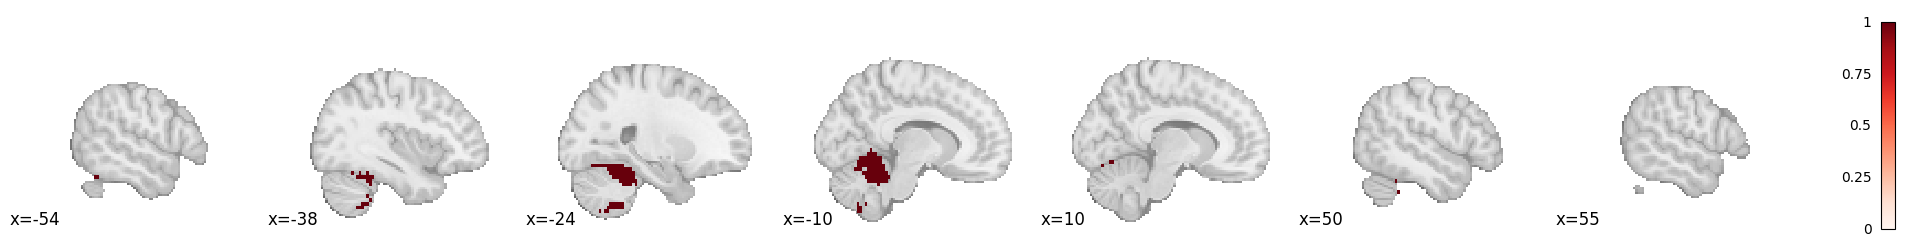

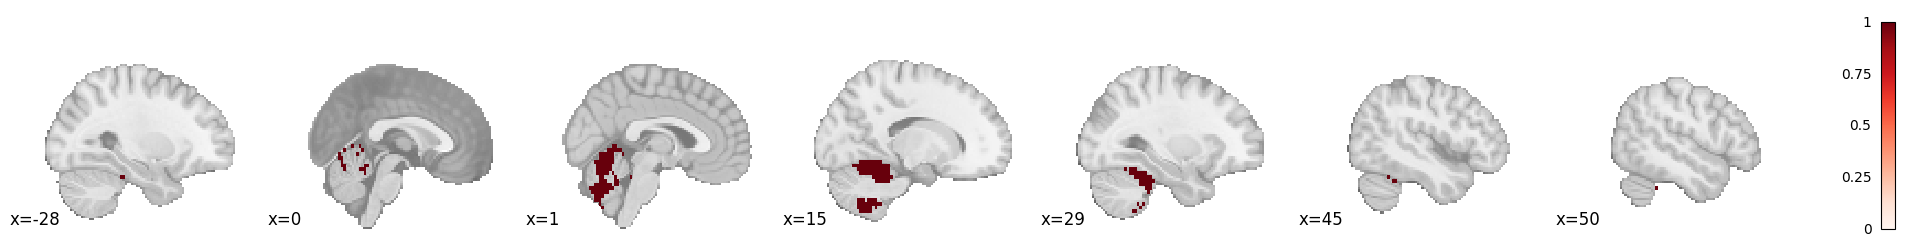

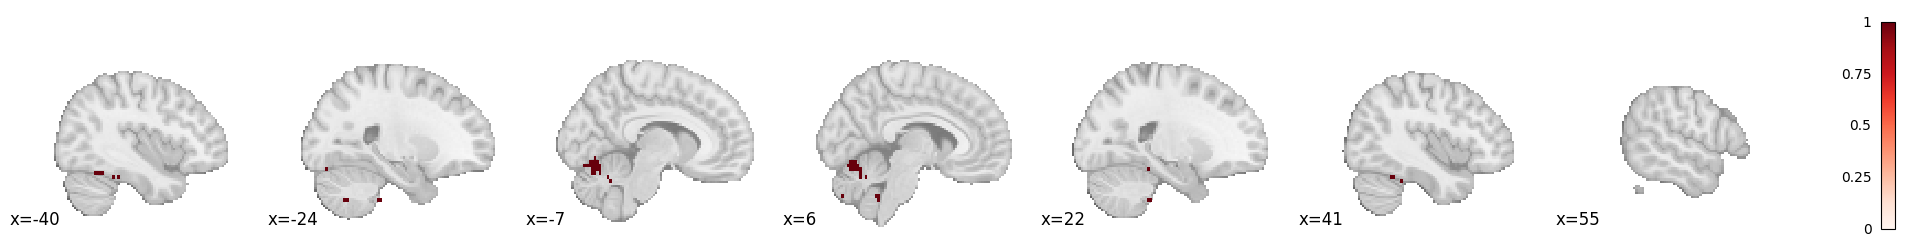

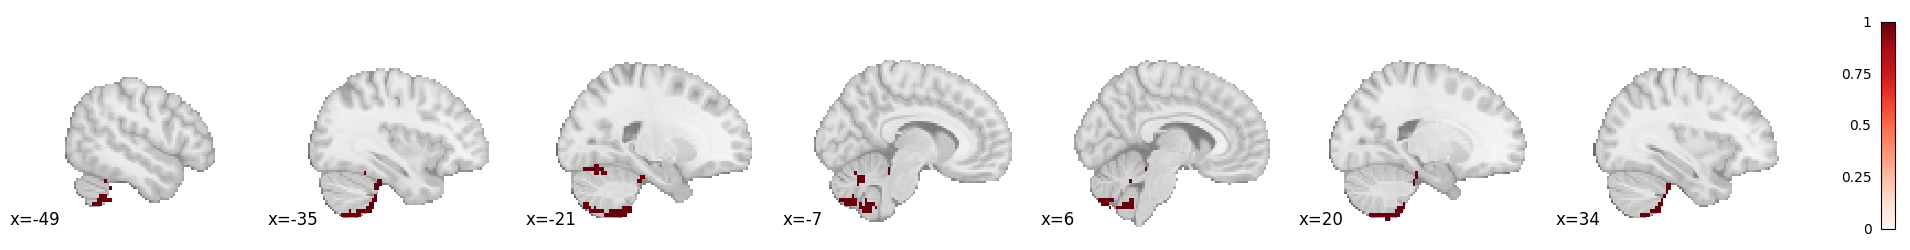

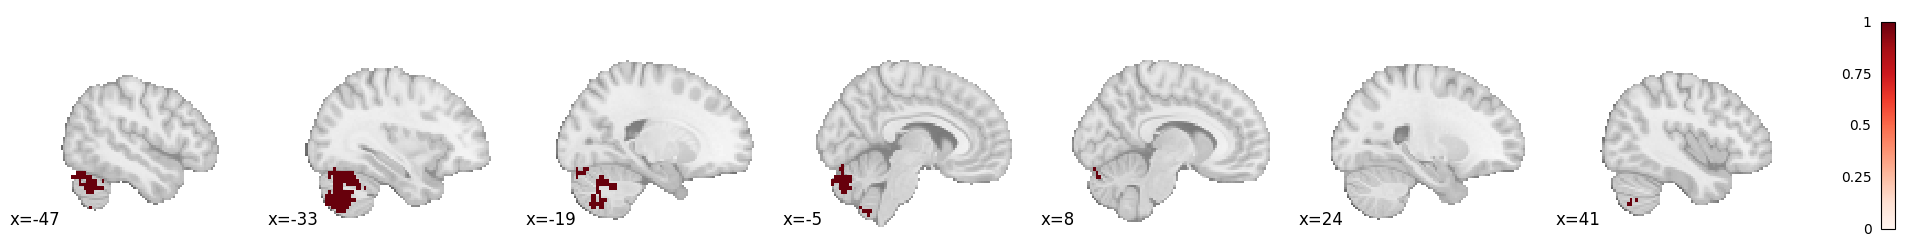

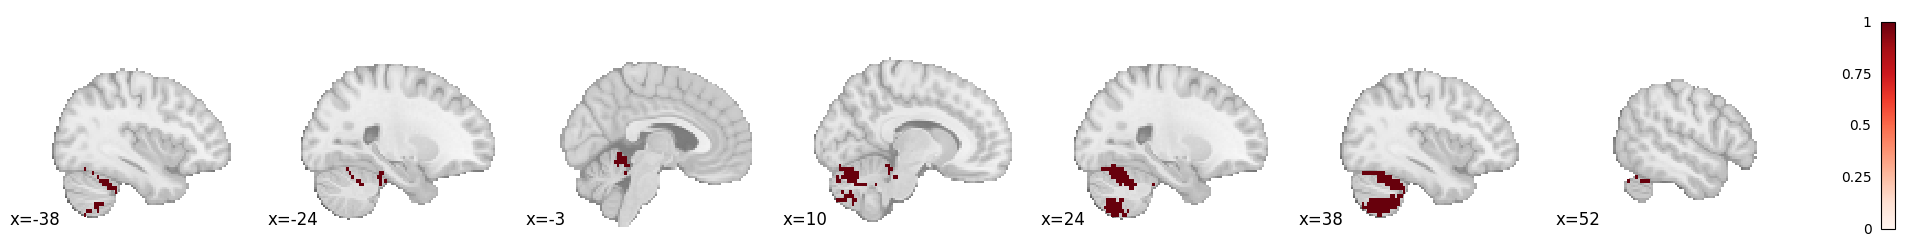

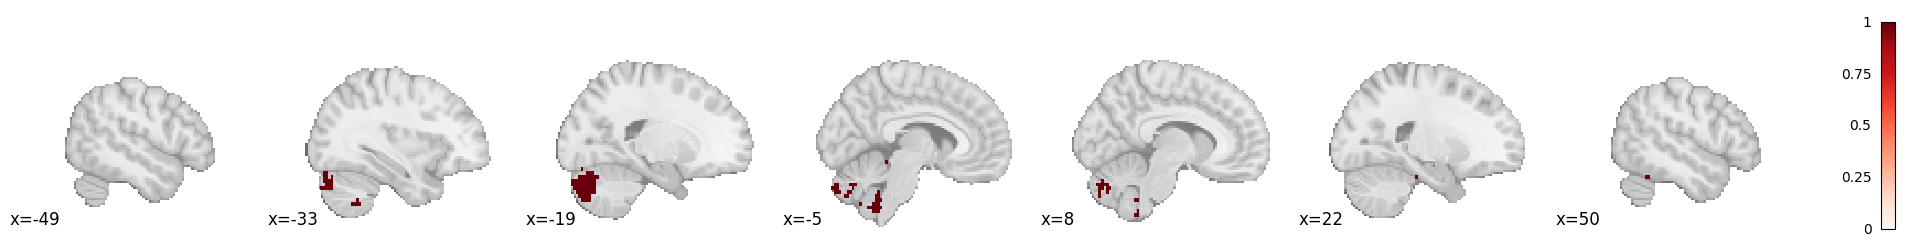

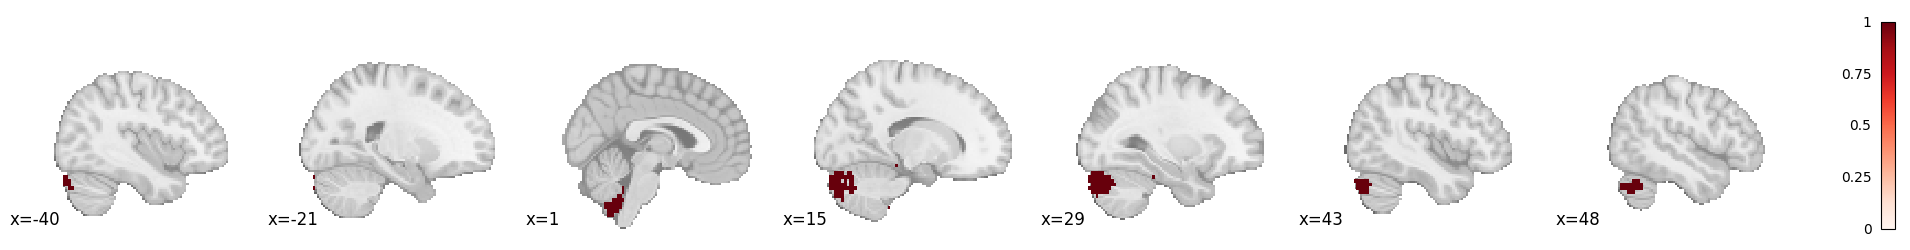

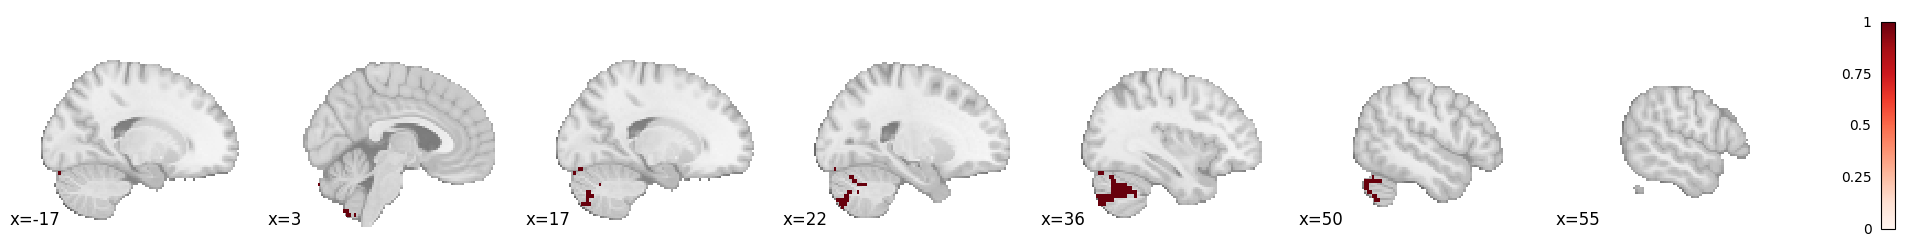

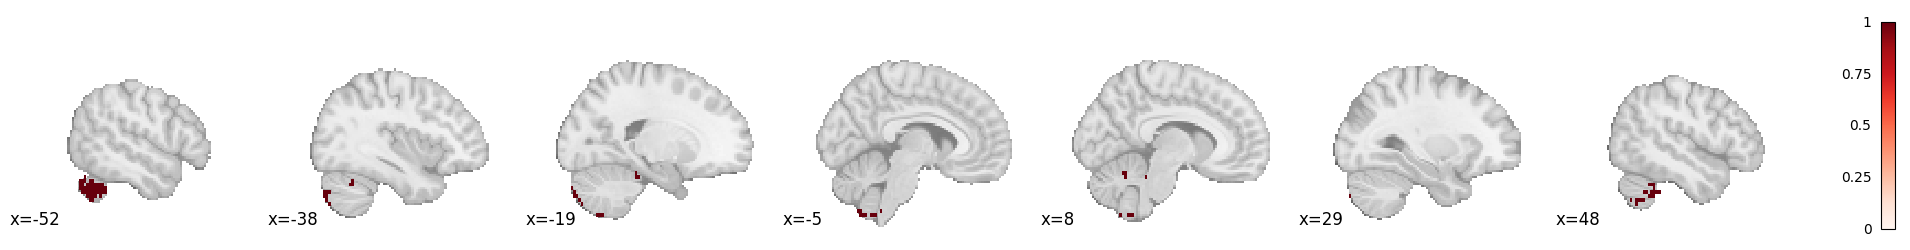

In [19]:
# Import ROIs
for n in range(len(mdtbcb_roi_names)):
    temp_roi = Brain_Data(mdtbcb_roi_list[n], mask=mdtbcb_roi_list[n])
    
    plot_stat_map(temp_roi.to_nifti(), 
                 display_mode='x',
                 cmap='Reds')

## Hypothesis
**The vmPFC will be sensitive to the valence of trials**

In [20]:
task = 'social'

subj_t1 = bids_dir+"derivatives/fmriprep/"+subj+"/func/"+subj+"_task-"+task+"_run-1_space-MNI152NLin2009cAsym_desc-brain_mask.nii.gz"

func_files = []
for n in range(2):
    #func_files['run'+str(n+1)] = []
    for cond in conditions:
        temp_file = [x for x in file_list if task+'_'+cond+'_run-'+str(n+1)+'.nii' in x][0]
        func_files.append(temp_file)
#func_files = [x for x in file_list if 'tmap_'+task in x]
#func_files = [x for x in func_files if 'V' not in x]
#func_files.sort()
func_files


['/Volumes/HP-SOC-DOOR/social_doors/derivatives/social_doors-nilearn-indiv_runs/sub-010/zmap_social_negative_run-1.nii',
 '/Volumes/HP-SOC-DOOR/social_doors/derivatives/social_doors-nilearn-indiv_runs/sub-010/zmap_social_negative_win_run-1.nii',
 '/Volumes/HP-SOC-DOOR/social_doors/derivatives/social_doors-nilearn-indiv_runs/sub-010/zmap_social_negative_loss_run-1.nii',
 '/Volumes/HP-SOC-DOOR/social_doors/derivatives/social_doors-nilearn-indiv_runs/sub-010/zmap_social_positive_run-1.nii',
 '/Volumes/HP-SOC-DOOR/social_doors/derivatives/social_doors-nilearn-indiv_runs/sub-010/zmap_social_positive_win_run-1.nii',
 '/Volumes/HP-SOC-DOOR/social_doors/derivatives/social_doors-nilearn-indiv_runs/sub-010/zmap_social_positive_loss_run-1.nii',
 '/Volumes/HP-SOC-DOOR/social_doors/derivatives/social_doors-nilearn-indiv_runs/sub-010/zmap_social_negative_run-2.nii',
 '/Volumes/HP-SOC-DOOR/social_doors/derivatives/social_doors-nilearn-indiv_runs/sub-010/zmap_social_negative_win_run-2.nii',
 '/Volumes

In [34]:
betas.shape

<bound method Brain_Data.shape of nltools.data.brain_data.Brain_Data(data=(12, 238955), Y=(0, 0), X=(0, 0), mask=MNI152_T1_2mm_brain_mask.nii.gz)>

/opt/anaconda3/envs/nltools/lib/python3.11/site-packages/nltools/data/brain_data.py:239: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  self.data = self.nifti_masker.fit_transform(data)
/opt/anaconda3/envs/nltools/lib/python3.11/site-packages/nltools/data/brain_data.py:239: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You might want to provide a target_affine that is equal to the affine of the imgs or resample the mask beforehand to save memory and computation time.
  self.data = self.nifti_masker.fit_transform(data)
/opt/anaconda3/envs/nltools/lib/python3.11/site-packages/nltools/data/brain_data.py:239: UserWarning: Resampling binary images with continuous or linear interpolation. This might lead to unexpected results. You might consider using nearest interpolation instead.
  self.data = self.nifti_masker.fit_transform(data

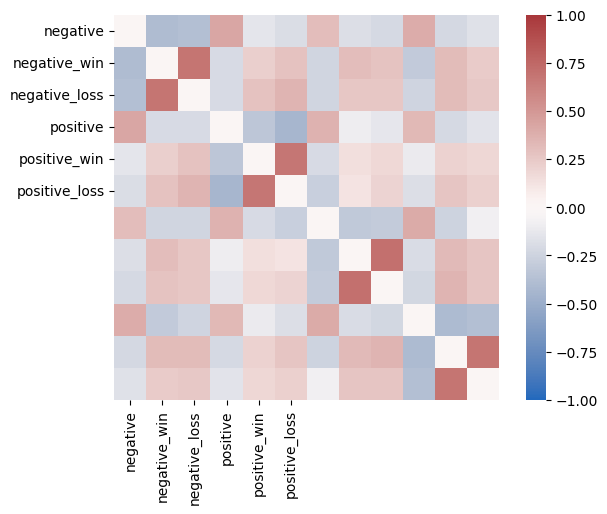

In [35]:
vmPFC_b_mask = Brain_Data(reward_roi_dict['vmPFC_b'])

betas = Brain_Data([f for f in func_files])

if betas.data.ndim == 1:
    betas.data = betas.data.reshape(len(func_files), -1)
    
out = 1 - betas.apply_mask(vmPFC_b_mask).distance(metric='correlation')
out.labels=conditions

f2 = out.plot(vmin=-1, vmax=1, cmap=sns.color_palette('vlag', as_cmap=True))

<Axes: >

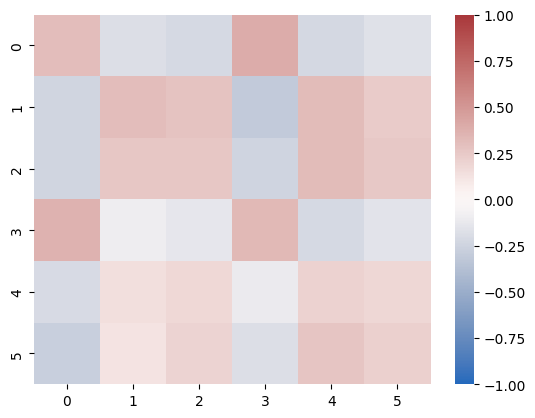

In [36]:
sns.heatmap(out.squareform()[0:6,-6:], vmin=-1, vmax=1, cmap=sns.color_palette('vlag', as_cmap=True))

<Axes: >

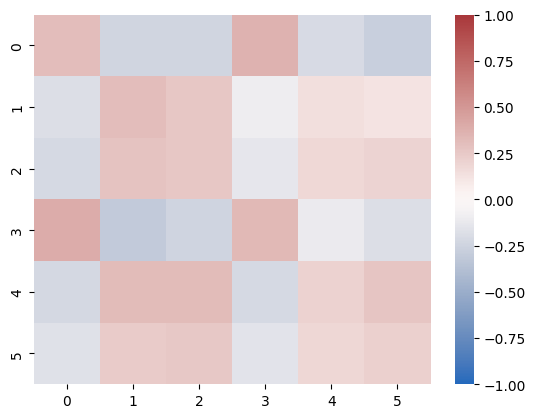

In [37]:
sns.heatmap(out.squareform()[-6:,:6], vmin=-1, vmax=1, cmap=sns.color_palette('vlag', as_cmap=True))

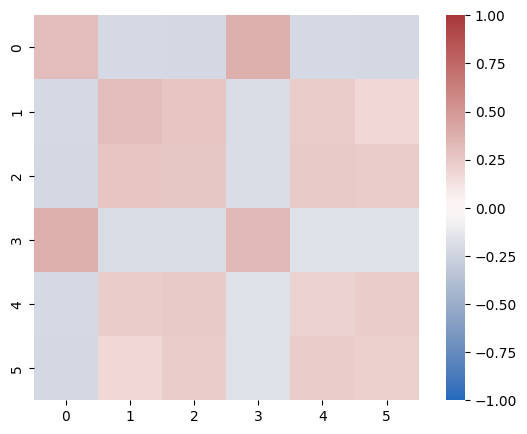

In [38]:
out_avg = Adjacency(out.squareform()[0:6,-6:])
out_avg = out_avg.append(Adjacency(out.squareform()[-6:,0:6]))

out_avg.mean().plot(vmin=-1, vmax=1, cmap=sns.color_palette('vlag', as_cmap=True))

In [54]:
import warnings
warnings.simplefilter("ignore", UserWarning)

In [55]:
rois = list(social_roi_dict.values()) + list(mdtbcb_roi_dict.values()) + list(striat_roi_dict.values())
roi_names = [x + '-social' for x in social_roi_names] + mdtbcb_roi_names + striat_roi_names

In [56]:
from scipy import stats

In [57]:
def upper_tri_indexing(A):
    m = A.shape[0]
    r,c = np.triu_indices(m,1)
    return A[r,c]

In [58]:
valence_adj_upr = upper_tri_indexing(valence_adj.squareform())
correct_adj_upr = upper_tri_indexing(correct_adj.squareform())
crctexc_adj_upr = upper_tri_indexing(crctexc_adj.squareform())

In [59]:
all_sub_sim = {}

for n in range(len(roi_names)):
    all_sub_sim[roi_names[n]+'_mdoors'] = Adjacency()
    all_sub_sim[roi_names[n]+'_social'] = Adjacency()

all_sub_val_rsa = pd.DataFrame(columns=['subj','group','task','roi','r'])
all_sub_cor_rsa = pd.DataFrame(columns=['subj','group','task','roi','r'])
all_sub_cex_rsa = pd.DataFrame(columns=['subj','group','task','roi','r'])

rois = list(social_roi_dict.values()) + list(mdtbcb_roi_dict.values()) + list(striat_roi_dict.values())
roi_names = [x + '-social' for x in social_roi_names] + mdtbcb_roi_names + striat_roi_names

for subj in subjs_list:
    file_list = glob.glob(os.path.join(data_dir, subj, f'zmap*.nii'))
    file_list.sort()
    
    group_id = subjs_scan_info[subjs_scan_info['participant_id'] == subj]['group'].iloc[0]
    
    print('Calculating similarities for '+subj)
    
    for task in ['mdoors', 'social']:
        subj_t1 = bids_dir+"derivatives/fmriprep/"+subj+"/func/"+subj+"_task-"+task+"_run-1_space-MNI152NLin2009cAsym_desc-brain_mask.nii.gz"
        #subj_suit = bids_dir+'derivatives/social_doors/'+subj+'/suit/iw_c_'+subj+'_run-1_space-MNI152NLin2009cAsym_desc-preproc_T1w_pcereb_u_a_'+subj+'_run-1_space-MNI152NLin2009cAsym_label-GM_probseg.nii'
        subj_suit = bids_dir+'derivatives/fmriprep/'+subj+'/anat/'+subj+'_run-1_space-MNI152NLin2009cAsym_desc-preproc_T1w_cerebellum_dseg.nii.gz'
        
        # Check if there are two task runs
        raw_runs = glob.glob(os.path.join('derivatives','fmriprep',subj,'func',
                                          subj+'_task-'+task+f'_run-*_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz'))
        
        if len(raw_runs) < 2:
            continue
        else:
        
            func_files = []
            suit_files = []
            for n in range(2):
                for cond in conditions:
                    temp_file = [x for x in file_list if task+'_'+cond+'_run-'+str(n+1)+'.nii' in x][0]
                    func_files.append(temp_file)
                    
                    suit_files.append(glob.glob(os.path.join(data_dir, subj, 'suit', 
                                   f'iw_wdzmap_'+task+'_'+cond+'_run-'+str(n+1)+'_u_a_'+subj+'_run-1_space-MNI152NLin2009cAsym_label-GM_probseg.nii'))[0])


            #suit_files = []
            ##for cond in conditions:
            #    suit_files.append(glob.glob(os.path.join(data_dir, subj, 'suit', 
            #                       f'iw_wdtmap_'+task+'_'+cond+'_run'+str(n+1)+'_u_a_'+subj+'_run-1_space-MNI152NLin2009cAsym_label-GM_probseg.nii'))[0])
            #suit_files = [x for x in suit_files if 'V' not in x]
            #suit_files.sort()


            if len(func_files) < 6:
                continue
            else:

                #func_files = []
                #for cond in conditions:
                #    temp_file = [x for x in file_list if task+'_'+cond+'.nii' in x][0]
                #    func_files.append(temp_file)

                betas = Brain_Data(func_files, mask=subj_t1)
                betas_suit = Brain_Data(suit_files, mask=subj_suit)

                if betas.data.ndim == 1:
                    betas.data = betas.data.reshape(len(func_files), -1)

                if betas_suit.data.ndim == 1:
                    betas_suit.data = betas_suit.data.reshape(len(suit_files), -1)

                for n in range(len(rois)):
                    temp_mask = Brain_Data(rois[n], mask=subj_t1)

                    if betas.apply_mask(temp_mask).data.shape[1] == 0:
                        continue
                    else:

                        if 'region' in roi_names[n]:
                            temp_mask_suit = Brain_Data(rois[n], mask=subj_suit)
                            sub_pattern_sim = betas_suit.apply_mask(temp_mask_suit).distance(metric='correlation')
                        else:
                            sub_pattern_sim = betas.apply_mask(temp_mask).distance(metric='correlation')
                        
                        # Average run 1 and run 2 condition correlations
                        sub_pattern_sim_avg = Adjacency(sub_pattern_sim.squareform()[0:6,-6:])
                        sub_pattern_sim_avg = sub_pattern_sim_avg.append(Adjacency(sub_pattern_sim.squareform()[-6:,0:6]))
                        
                        sub_pattern_sim_avg = sub_pattern_sim_avg.mean()
                        
                        sub_pattern_sim_avg.labels = conditions

                        all_sub_sim[roi_names[n]+'_'+task] = all_sub_sim[roi_names[n]+'_'+task].append(sub_pattern_sim_avg)
                        
                        
                        # Since neural RDMs are not exactly symetrical, take upper triangle of all RDMs
                        sub_pattern_sim_upr = upper_tri_indexing(sub_pattern_sim_avg.squareform())
                        
                        
                        s_val = stats.spearmanr(sub_pattern_sim_upr, valence_adj_upr)
                        s_cor = stats.spearmanr(sub_pattern_sim_upr, correct_adj_upr)
                        s_cex = stats.spearmanr(sub_pattern_sim_upr, crctexc_adj_upr)

                        
                        #s_val = sub_pattern_sim_avg.similarity(valence_adj, metric='spearman', perm_type=None)
                        #s_cor = sub_pattern_sim_avg.similarity(correct_adj, metric='spearman', n_permute=0)
                        #s_cex = sub_pattern_sim_avg.similarity(crctexc_adj, metric='spearman', n_permute=0)


                        #all_sub_sim[subj] = s_hyp1['correlation']
                        #all_sub_val_rsa = all_sub_val_rsa.append({'subj':subj, 'group':group_id,
                        #                                                      'task':task,
                        #                                                      'roi':roi_names[n],
                        #                                                      'r':s_val.correlation},
                        #                                                    ignore_index=True)

                        temp_val_df = pd.DataFrame({'subj':subj, 
                                                    'group':group_id,
                                                    'task':task,
                                                    'roi':roi_names[n],
                                                    'r':s_val.correlation}, index=[0])
                        all_sub_val_rsa = pd.concat([all_sub_val_rsa, temp_val_df],
                                                   ignore_index=True)
                        temp_cor_df = pd.DataFrame({'subj':subj, 
                                                    'group':group_id,
                                                    'task':task,
                                                    'roi':roi_names[n],
                                                    'r':s_cor.correlation}, index=[0])
                        all_sub_cor_rsa = pd.concat([all_sub_cor_rsa, temp_cor_df],
                                                   ignore_index=True)
                        temp_cex_df = pd.DataFrame({'subj':subj, 
                                                    'group':group_id,
                                                    'task':task,
                                                    'roi':roi_names[n],
                                                    'r':s_cex.correlation}, index=[0])
                        all_sub_cex_rsa = pd.concat([all_sub_cex_rsa, temp_cex_df],
                                                   ignore_index=True)



Calculating similarities for sub-010


/opt/anaconda3/envs/nltools/lib/python3.11/site-packages/nltools/data/brain_data.py:263: RuntimeWarning: NaNs or infinite values are present in the data passed to resample. This is a bad thing as they make resampling ill-defined and much slower.
  self.nifti_masker.fit_transform(nib.load(to_load))
/opt/anaconda3/envs/nltools/lib/python3.11/site-packages/nltools/data/brain_data.py:263: RuntimeWarning: NaNs or infinite values are present in the data passed to resample. This is a bad thing as they make resampling ill-defined and much slower.
  self.nifti_masker.fit_transform(nib.load(to_load))
/opt/anaconda3/envs/nltools/lib/python3.11/site-packages/nltools/data/brain_data.py:263: RuntimeWarning: NaNs or infinite values are present in the data passed to resample. This is a bad thing as they make resampling ill-defined and much slower.
  self.nifti_masker.fit_transform(nib.load(to_load))
/opt/anaconda3/envs/nltools/lib/python3.11/site-packages/nltools/data/brain_data.py:263: RuntimeWarning

Calculating similarities for sub-013


/opt/anaconda3/envs/nltools/lib/python3.11/site-packages/nltools/data/brain_data.py:263: RuntimeWarning: NaNs or infinite values are present in the data passed to resample. This is a bad thing as they make resampling ill-defined and much slower.
  self.nifti_masker.fit_transform(nib.load(to_load))
/opt/anaconda3/envs/nltools/lib/python3.11/site-packages/nltools/data/brain_data.py:263: RuntimeWarning: NaNs or infinite values are present in the data passed to resample. This is a bad thing as they make resampling ill-defined and much slower.
  self.nifti_masker.fit_transform(nib.load(to_load))
/opt/anaconda3/envs/nltools/lib/python3.11/site-packages/nltools/data/brain_data.py:263: RuntimeWarning: NaNs or infinite values are present in the data passed to resample. This is a bad thing as they make resampling ill-defined and much slower.
  self.nifti_masker.fit_transform(nib.load(to_load))
/opt/anaconda3/envs/nltools/lib/python3.11/site-packages/nltools/data/brain_data.py:263: RuntimeWarning

Calculating similarities for sub-028


...

/opt/anaconda3/envs/nltools/lib/python3.11/site-packages/nltools/data/brain_data.py:263: RuntimeWarning: NaNs or infinite values are present in the data passed to resample. This is a bad thing as they make resampling ill-defined and much slower.
  self.nifti_masker.fit_transform(nib.load(to_load))
/opt/anaconda3/envs/nltools/lib/python3.11/site-packages/nltools/data/brain_data.py:263: RuntimeWarning: NaNs or infinite values are present in the data passed to resample. This is a bad thing as they make resampling ill-defined and much slower.
  self.nifti_masker.fit_transform(nib.load(to_load))
/opt/anaconda3/envs/nltools/lib/python3.11/site-packages/nltools/data/brain_data.py:263: RuntimeWarning: NaNs or infinite values are present in the data passed to resample. This is a bad thing as they make resampling ill-defined and much slower.
  self.nifti_masker.fit_transform(nib.load(to_load))
/opt/anaconda3/envs/nltools/lib/python3.11/site-packages/nltools/data/brain_data.py:263: RuntimeWarning

Calculating similarities for sub-6005


/opt/anaconda3/envs/nltools/lib/python3.11/site-packages/nltools/data/brain_data.py:263: RuntimeWarning: NaNs or infinite values are present in the data passed to resample. This is a bad thing as they make resampling ill-defined and much slower.
  self.nifti_masker.fit_transform(nib.load(to_load))
/opt/anaconda3/envs/nltools/lib/python3.11/site-packages/nltools/data/brain_data.py:263: RuntimeWarning: NaNs or infinite values are present in the data passed to resample. This is a bad thing as they make resampling ill-defined and much slower.
  self.nifti_masker.fit_transform(nib.load(to_load))
/opt/anaconda3/envs/nltools/lib/python3.11/site-packages/nltools/data/brain_data.py:263: RuntimeWarning: NaNs or infinite values are present in the data passed to resample. This is a bad thing as they make resampling ill-defined and much slower.
  self.nifti_masker.fit_transform(nib.load(to_load))
/opt/anaconda3/envs/nltools/lib/python3.11/site-packages/nltools/data/brain_data.py:263: RuntimeWarning

Calculating similarities for sub-6006


/opt/anaconda3/envs/nltools/lib/python3.11/site-packages/nltools/data/brain_data.py:263: RuntimeWarning: NaNs or infinite values are present in the data passed to resample. This is a bad thing as they make resampling ill-defined and much slower.
  self.nifti_masker.fit_transform(nib.load(to_load))
/opt/anaconda3/envs/nltools/lib/python3.11/site-packages/nltools/data/brain_data.py:263: RuntimeWarning: NaNs or infinite values are present in the data passed to resample. This is a bad thing as they make resampling ill-defined and much slower.
  self.nifti_masker.fit_transform(nib.load(to_load))
/opt/anaconda3/envs/nltools/lib/python3.11/site-packages/nltools/data/brain_data.py:263: RuntimeWarning: NaNs or infinite values are present in the data passed to resample. This is a bad thing as they make resampling ill-defined and much slower.
  self.nifti_masker.fit_transform(nib.load(to_load))
/opt/anaconda3/envs/nltools/lib/python3.11/site-packages/nltools/data/brain_data.py:263: RuntimeWarning

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22],
 [Text(0, 0, 'AMG_r-social'),
  Text(1, 0, 'ATL_b-social'),
  Text(2, 0, 'ATL_l-social'),
  Text(3, 0, 'ATL_r-social'),
  Text(4, 0, 'C1_r-social'),
  Text(5, 0, 'PCC_b-social'),
  Text(6, 0, 'TPJ_b-social'),
  Text(7, 0, 'TPJ_l-social'),
  Text(8, 0, 'TPJ_r-social'),
  Text(9, 0, 'dmPFC_b-social'),
  Text(10, 0, 'region01'),
  Text(11, 0, 'region02'),
  Text(12, 0, 'region03'),
  Text(13, 0, 'region04'),
  Text(14, 0, 'region05'),
  Text(15, 0, 'region06'),
  Text(16, 0, 'region07'),
  Text(17, 0, 'region08'),
  Text(18, 0, 'region09'),
  Text(19, 0, 'region10'),
  Text(20, 0, 'striatum_dorsala'),
  Text(21, 0, 'striatum_dorsalp'),
  Text(22, 0, 'striatum_ventral')])

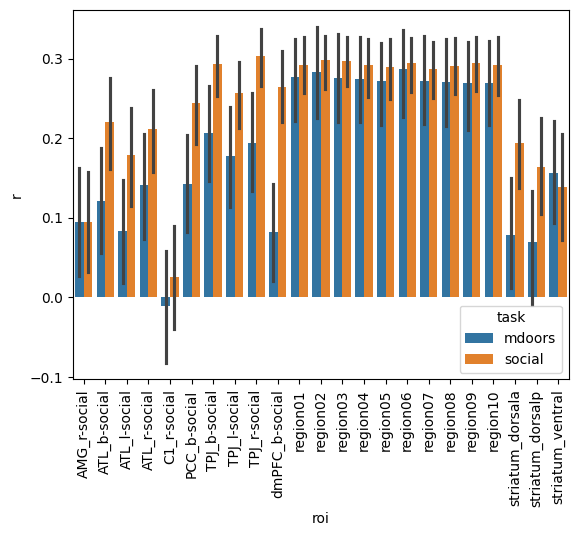

In [60]:
sns.barplot(x='roi',y='r',hue='task', data=all_sub_cex_rsa)
plt.xticks(rotation=90)
#sns.stripplot(x='roi',y='r',hue='task', data=all_sub_val_rsa)

<Axes: xlabel='roi', ylabel='r'>

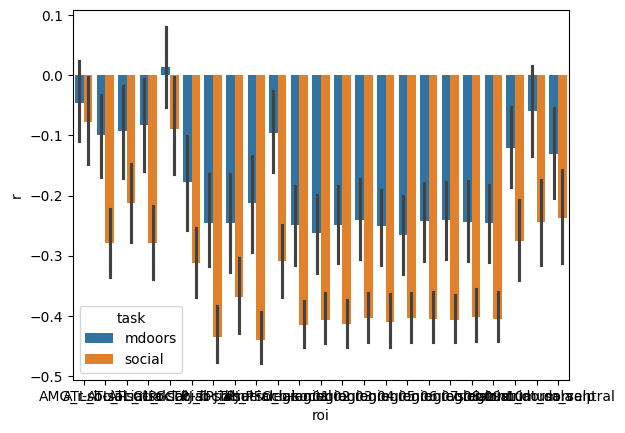

In [61]:
sns.barplot(x='roi',y='r',hue='task', data=all_sub_cor_rsa)
#sns.stripplot(x='roi',y='r',hue='task', data=all_sub_cor_rsa_adole)

In [62]:
#all_sub_sim_val_win.to_csv(outp_dir+'/valence_win_similarity.csv', index=False)
all_sub_val_rsa.to_csv(outp_dir+'/valence_rdm_similarity.csv', index=False)
all_sub_cor_rsa.to_csv(outp_dir+'/correct_rdm_similarity.csv', index=False)
all_sub_cex_rsa.to_csv(outp_dir+'/crctexc_rdm_similarity.csv', index=False)


## Individual condition pattern analysis

In [64]:
all_sub_sim_val_win = pd.DataFrame(columns=['subj','group','task','roi','r'])

#rois = list(rlearn_roi_dict.values()) + list(social_roi_dict.values())
#roi_names = [x + '-rlearn' for x in rlearn_roi_names] + [x + '-social' for x in social_roi_names]

#for roi in roi_names:
#    all_sub_sim[roi] = Brain_Data(mask=subj_t1)

for subj in subjs_list:
    file_list = glob.glob(os.path.join(data_dir, subj, f'zmap*.nii'))
    file_list.sort()
    
    group_id = subjs_scan_info[subjs_scan_info['participant_id'] == subj]['group'].iloc[0]
    
    print('Calculating similarities for '+subj)
    
    for task in ['mdoors','social']:
    
        subj_t1 = bids_dir+"derivatives/fmriprep/"+subj+"/anat/"+subj+"_space-MNI152NLin2009cAsym_label-GM_probseg_bin.nii.gz"
        subj_suit = bids_dir+'derivatives/fmriprep/'+subj+'/anat/'+subj+'_run-1_space-MNI152NLin2009cAsym_desc-preproc_T1w_cerebellum_dseg.nii.gz'

        raw_runs = glob.glob(os.path.join('derivatives','fmriprep',subj,'func',
                                          subj+'_task-'+task+f'_run-*_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz'))
        
        if len(raw_runs) < 2:
            continue
        else:
        
            func_files = []
            suit_files = []
            for n in range(2):
                for cond in conditions:
                    temp_file = [x for x in file_list if task+'_'+cond+'_run-'+str(n+1)+'.nii' in x][0]
                    func_files.append(temp_file)
                    
                    suit_files.append(glob.glob(os.path.join(data_dir, subj, 'suit', 
                                   f'iw_wdzmap_'+task+'_'+cond+'_run-'+str(n+1)+'_u_a_'+subj+'_run-1_space-MNI152NLin2009cAsym_label-GM_probseg.nii'))[0])


            #suit_files = []
            #for cond in conditions:
            #    suit_files.append(glob.glob(os.path.join(data_dir, subj, 'suit', 
            #                       f'iw_wdtmap_'+task+'_'+cond+'_u_a_'+subj+'_run-1_space-MNI152NLin2009cAsym_label-GM_probseg.nii'))[0])
            #suit_files = [x for x in suit_files if 'V' not in x]
            #suit_files.sort()

            if len(func_files) < 6:
                continue
            else:

                pos_win_file_run1 = [x for x in func_files if 'positive_win_run-1' in x][0]
                neg_win_file_run1 = [x for x in func_files if 'negative_win_run-1' in x][0]
                pos_win_file_run2 = [x for x in func_files if 'positive_win_run-2' in x][0]
                neg_win_file_run2 = [x for x in func_files if 'negative_win_run-2' in x][0]

                beta_pos_win_run1 = Brain_Data(pos_win_file_run1, mask=subj_t1)
                beta_neg_win_run1 = Brain_Data(neg_win_file_run1, mask=subj_t1)
                beta_pos_win_run2 = Brain_Data(pos_win_file_run2, mask=subj_t1)
                beta_neg_win_run2 = Brain_Data(neg_win_file_run2, mask=subj_t1)
                
                

                for n in range(len(rois)):
                    
                    if 'region' in roi_names[n]:
                        pos_win_file_run1 = [x for x in suit_files if 'positive_win_run-1' in x][0]
                        neg_win_file_run1 = [x for x in suit_files if 'negative_win_run-1' in x][0]
                        pos_win_file_run2 = [x for x in suit_files if 'positive_win_run-2' in x][0]
                        neg_win_file_run2 = [x for x in suit_files if 'negative_win_run-2' in x][0]

                        beta_pos_win_run1 = Brain_Data(pos_win_file_run1, mask=subj_suit)
                        beta_neg_win_run1 = Brain_Data(neg_win_file_run1, mask=subj_suit)
                        beta_pos_win_run2 = Brain_Data(pos_win_file_run2, mask=subj_suit)
                        beta_neg_win_run2 = Brain_Data(neg_win_file_run2, mask=subj_suit)
                        
                        temp_mask = Brain_Data(rois[n], mask=subj_suit)
                        
                    else:
                        pos_win_file_run1 = [x for x in func_files if 'positive_win_run-1' in x][0]
                        neg_win_file_run1 = [x for x in func_files if 'negative_win_run-1' in x][0]
                        pos_win_file_run2 = [x for x in func_files if 'positive_win_run-2' in x][0]
                        neg_win_file_run2 = [x for x in func_files if 'negative_win_run-2' in x][0]

                        beta_pos_win_run1 = Brain_Data(pos_win_file_run1, mask=subj_t1)
                        beta_neg_win_run1 = Brain_Data(neg_win_file_run1, mask=subj_t1)
                        beta_pos_win_run2 = Brain_Data(pos_win_file_run2, mask=subj_t1)
                        beta_neg_win_run2 = Brain_Data(neg_win_file_run2, mask=subj_t1)
                    
                        temp_mask = Brain_Data(rois[n], mask=subj_t1)

                    if beta_pos_win_run1.apply_mask(temp_mask).data.shape[0] == 0:
                        continue
                    else:
                        sub_pattern_pos_win_run1 = beta_pos_win_run1.apply_mask(temp_mask).data
                        sub_pattern_neg_win_run1 = beta_neg_win_run1.apply_mask(temp_mask).data
                        sub_pattern_pos_win_run2 = beta_pos_win_run2.apply_mask(temp_mask).data
                        sub_pattern_neg_win_run2 = beta_neg_win_run2.apply_mask(temp_mask).data

                        temp_corr1 = stats.spearmanr(sub_pattern_pos_win_run1, sub_pattern_neg_win_run2).correlation
                        temp_corr2 = stats.spearmanr(sub_pattern_pos_win_run2, sub_pattern_neg_win_run1).correlation
                        
                        temp_corr = np.mean([temp_corr1, temp_corr2])

                        temp_df = pd.DataFrame({'subj':subj, 'group':group_id,
                                              'task':task,
                                              'roi':roi_names[n],
                                              'r':temp_corr}, index=[0])
                        all_sub_sim_val_win = pd.concat([all_sub_sim_val_win, temp_df], ignore_index=True)


                

Calculating similarities for sub-010


/var/folders/bj/bjn1471s0735c7771plnzsz00000gn/T/ipykernel_5438/701120394.py:108: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_sub_sim_val_win = pd.concat([all_sub_sim_val_win, temp_df], ignore_index=True)
/opt/anaconda3/envs/nltools/lib/python3.11/site-packages/nltools/data/brain_data.py:239: RuntimeWarning: NaNs or infinite values are present in the data passed to resample. This is a bad thing as they make resampling ill-defined and much slower.
  self.data = self.nifti_masker.fit_transform(data)
/opt/anaconda3/envs/nltools/lib/python3.11/site-packages/nltools/data/brain_data.py:239: RuntimeWarning: NaNs or infinite values are present in the data passed to resample. This is a bad thing as they make resampling ill-defined and much slo

Calculating similarities for sub-013


/opt/anaconda3/envs/nltools/lib/python3.11/site-packages/nltools/data/brain_data.py:239: RuntimeWarning: NaNs or infinite values are present in the data passed to resample. This is a bad thing as they make resampling ill-defined and much slower.
  self.data = self.nifti_masker.fit_transform(data)
/opt/anaconda3/envs/nltools/lib/python3.11/site-packages/nltools/data/brain_data.py:239: RuntimeWarning: NaNs or infinite values are present in the data passed to resample. This is a bad thing as they make resampling ill-defined and much slower.
  self.data = self.nifti_masker.fit_transform(data)
/opt/anaconda3/envs/nltools/lib/python3.11/site-packages/nltools/data/brain_data.py:239: RuntimeWarning: NaNs or infinite values are present in the data passed to resample. This is a bad thing as they make resampling ill-defined and much slower.
  self.data = self.nifti_masker.fit_transform(data)
/opt/anaconda3/envs/nltools/lib/python3.11/site-packages/nltools/data/brain_data.py:239: RuntimeWarning: N

Calculating similarities for sub-028


...

/opt/anaconda3/envs/nltools/lib/python3.11/site-packages/nltools/data/brain_data.py:239: RuntimeWarning: NaNs or infinite values are present in the data passed to resample. This is a bad thing as they make resampling ill-defined and much slower.
  self.data = self.nifti_masker.fit_transform(data)
/opt/anaconda3/envs/nltools/lib/python3.11/site-packages/nltools/data/brain_data.py:239: RuntimeWarning: NaNs or infinite values are present in the data passed to resample. This is a bad thing as they make resampling ill-defined and much slower.
  self.data = self.nifti_masker.fit_transform(data)
/opt/anaconda3/envs/nltools/lib/python3.11/site-packages/nltools/data/brain_data.py:239: RuntimeWarning: NaNs or infinite values are present in the data passed to resample. This is a bad thing as they make resampling ill-defined and much slower.
  self.data = self.nifti_masker.fit_transform(data)
/opt/anaconda3/envs/nltools/lib/python3.11/site-packages/nltools/data/brain_data.py:239: RuntimeWarning: N

Calculating similarities for sub-6005


/opt/anaconda3/envs/nltools/lib/python3.11/site-packages/nltools/data/brain_data.py:239: RuntimeWarning: NaNs or infinite values are present in the data passed to resample. This is a bad thing as they make resampling ill-defined and much slower.
  self.data = self.nifti_masker.fit_transform(data)
/opt/anaconda3/envs/nltools/lib/python3.11/site-packages/nltools/data/brain_data.py:239: RuntimeWarning: NaNs or infinite values are present in the data passed to resample. This is a bad thing as they make resampling ill-defined and much slower.
  self.data = self.nifti_masker.fit_transform(data)
/opt/anaconda3/envs/nltools/lib/python3.11/site-packages/nltools/data/brain_data.py:239: RuntimeWarning: NaNs or infinite values are present in the data passed to resample. This is a bad thing as they make resampling ill-defined and much slower.
  self.data = self.nifti_masker.fit_transform(data)
/opt/anaconda3/envs/nltools/lib/python3.11/site-packages/nltools/data/brain_data.py:239: RuntimeWarning: N

Calculating similarities for sub-6006


/opt/anaconda3/envs/nltools/lib/python3.11/site-packages/nltools/data/brain_data.py:239: RuntimeWarning: NaNs or infinite values are present in the data passed to resample. This is a bad thing as they make resampling ill-defined and much slower.
  self.data = self.nifti_masker.fit_transform(data)
/opt/anaconda3/envs/nltools/lib/python3.11/site-packages/nltools/data/brain_data.py:239: RuntimeWarning: NaNs or infinite values are present in the data passed to resample. This is a bad thing as they make resampling ill-defined and much slower.
  self.data = self.nifti_masker.fit_transform(data)
/opt/anaconda3/envs/nltools/lib/python3.11/site-packages/nltools/data/brain_data.py:239: RuntimeWarning: NaNs or infinite values are present in the data passed to resample. This is a bad thing as they make resampling ill-defined and much slower.
  self.data = self.nifti_masker.fit_transform(data)
/opt/anaconda3/envs/nltools/lib/python3.11/site-packages/nltools/data/brain_data.py:239: RuntimeWarning: N

In [65]:
all_sub_sim_val_win.to_csv(outp_dir+'/corrval_rdm_similarity.csv', index=False)

In [66]:
all_sub_sim_val_win


,subj,group,task,roi,r
0,sub-010,kid,mdoors,AMG_r-social,0.260896
1,sub-010,kid,mdoors,ATL_b-social,0.035380
2,sub-010,kid,mdoors,ATL_l-social,-0.036617
3,sub-010,kid,mdoors,ATL_r-social,0.140167
4,sub-010,kid,mdoors,C1_r-social,0.012500
...,...,...,...,...,...
2801,sub-6006,college,social,region09,0.045061
2802,sub-6006,college,social,region10,0.049624
2803,sub-6006,college,social,striatum_dorsala,-0.022952
2804,sub-6006,college,social,striatum_dorsalp,-0.066864


In [67]:
all_sub_cex_rsa

,subj,group,task,roi,r
0,sub-010,kid,mdoors,AMG_r-social,0.408529
1,sub-010,kid,mdoors,ATL_b-social,0.317744
2,sub-010,kid,mdoors,ATL_l-social,0.136176
3,sub-010,kid,mdoors,ATL_r-social,0.226960
4,sub-010,kid,mdoors,C1_r-social,-0.045392
...,...,...,...,...,...
2801,sub-6006,college,social,region09,0.045392
2802,sub-6006,college,social,region10,0.045392
2803,sub-6006,college,social,striatum_dorsala,-0.090784
2804,sub-6006,college,social,striatum_dorsalp,-0.363137


<Axes: xlabel='roi', ylabel='r'>

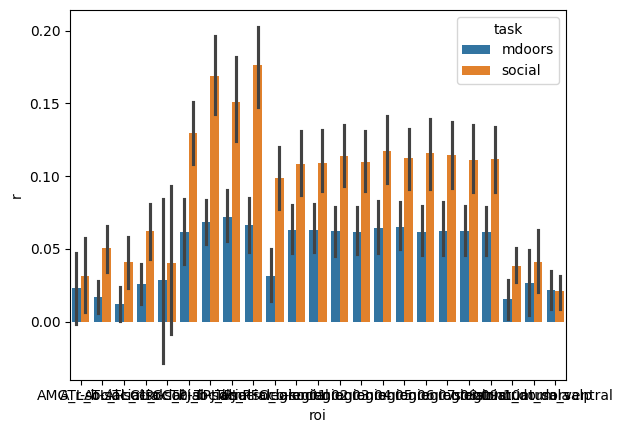

In [68]:
sns.barplot(x='roi',y='r',hue='task', data=all_sub_sim_val_win)
#sns.stripplot(x='roi',y='r',hue='task', data=all_sub_sim_val_win)


# ROI to ROI RSA

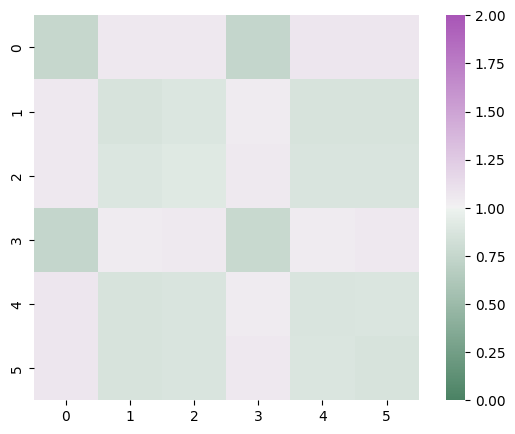

In [69]:
all_sub_sim['region06_social'].mean().plot(vmin=0, vmax=2,
                                           cmap=sns.diverging_palette(145, 300, s=60, as_cmap=True))

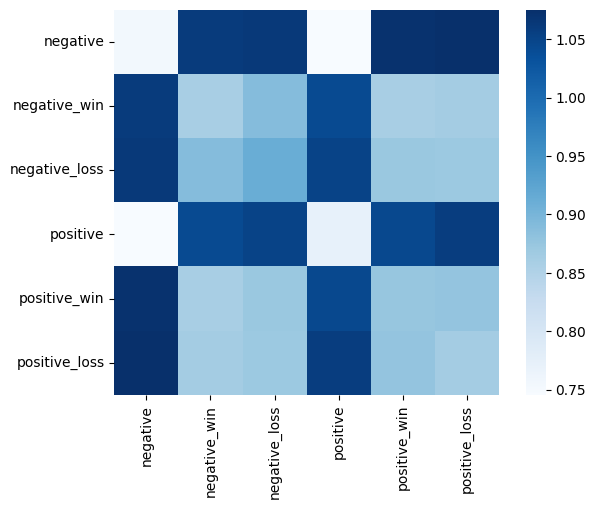

In [70]:
all_sub_sim['region06_social'].mean().plot(cmap=sns.color_palette("Blues", as_cmap=True),
                                           xticklabels=conditions,yticklabels=conditions)

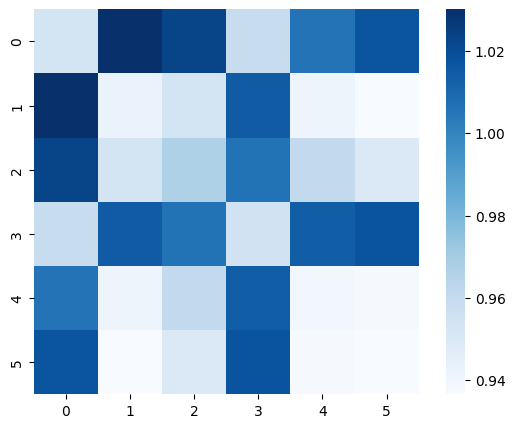

In [71]:
all_sub_sim['striatum_dorsalp_social'].mean().plot(cmap=sns.color_palette("Blues", as_cmap=True))

AttributeError: 'NoneType' object has no attribute 'saveplot'

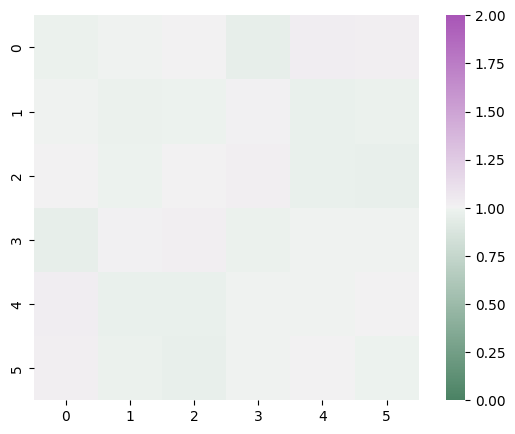

In [72]:
all_sub_sim_avg = {}

for roi in all_sub_sim.keys():
    all_sub_sim_avg[roi] = all_sub_sim[roi].mean()
    f = all_sub_sim_avg[roi].plot(vmin=0, vmax=2,
                             cmap=sns.diverging_palette(145, 300, s=60, as_cmap=True))
    f.saveplot(outp_dir+'/'+roi+'.png')